In [2]:
import neural_additive_models.data_utils as data_utils
import neural_additive_models.graph_builder as graph_builder

from utils import load_col_min_max, inverse_min_max_scaler

import numpy as np
from sklearn.model_selection import KFold, StratifiedKFold

# -----------------------------
# DATASET + task type
# -----------------------------
dataset_name = 'OpenML_WineRed'
is_regression = True   # Wine Red is a regression task

# This matches data_utils.load_dataset used in nam_train
data_x, data_y, column_names = data_utils.load_dataset(dataset_name)

# For plotting in original feature scale
col_min_max = load_col_min_max(dataset_name)

# -----------------------------
# Rebuild the same 5-fold splits as nam_train
# (same random_state as get_train_test_fold: 42)
# -----------------------------
NUM_FOLDS = 5
fold_test_indices = []
fold_train_indices = []

if is_regression:
    kfold = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
else:
    kfold = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)

all_splits = list(kfold.split(data_x, data_y))

for fold_num in range(1, NUM_FOLDS + 1):
    train_idx, test_idx = all_splits[fold_num - 1]
    fold_train_indices.append(train_idx)
    fold_test_indices.append(test_idx)

print(f"Fold test set sizes: {[len(idx) for idx in fold_test_indices]}")
print(f"Total test samples: {sum(len(idx) for idx in fold_test_indices)}")
print(f"Total dataset size: {len(data_x)}")
print(f"Test set percentage: {100 * sum(len(idx) for idx in fold_test_indices) / len(data_x):.1f}%")


Fold test set sizes: [1300, 1300, 1299, 1299, 1299]
Total test samples: 6497
Total dataset size: 6497
Test set percentage: 100.0%


In [3]:
from utils import prepare_feature_arrays, get_dataset_config

# Step 1: Prepare original-space arrays (for plotting x-axes)
SINGLE_FEATURES_ORIGINAL, UNIQUE_FEATURES_ORIGINAL, UNIQUE_FEATURES = prepare_feature_arrays(
    data_x, column_names, col_min_max, inverse_min_max_scaler
)

# Step 2: Dataset-specific config (for labels & categorical features)
COL_NAMES, FEATURE_LABEL_MAPPING, CATEGORICAL_NAMES = get_dataset_config(dataset_name, column_names)

print("Number of features:", len(column_names))
print("Categorical features:", CATEGORICAL_NAMES)


Number of features: 11
Categorical features: []


In [4]:
from utils import load_nam_checkpoint
from utils import get_test_predictions, compute_mean_predictions, get_feature_predictions

all_preds_per_fold = [[] for _ in range(NUM_FOLDS)]
all_hist_data = []
all_mean_pred = []

ROOT_LOGDIR = "./OpenML_WineRed"

for fold in range(1, NUM_FOLDS + 1):     # 5 folds
    fold_idx = fold - 1
    test_indices = fold_test_indices[fold_idx]
    print(f"\nProcessing fold {fold} (test set size: {len(test_indices)})...")
    
    for split in range(1, 4):            # 3 splits per fold (1..3)
        print(f"  Processing split {split}...")
        ckpt_dir = f"{ROOT_LOGDIR}/fold_{fold}/split_{split}/model_0/best_checkpoint"

        # 1) Restore NAM from checkpoint
        nam, sess = load_nam_checkpoint(ckpt_dir)

        # 2) Predictions on full dataset (needed for shapes + feature importance)
        preds_full = get_test_predictions(nam, data_x.astype(np.float32), sess)

        # 3) Store only test-set preds for RMSE (ensemble later)
        preds_test = preds_full[test_indices]
        all_preds_per_fold[fold_idx].append(preds_test)

        # 4) Shape functions for each feature
        feature_predictions = get_feature_predictions(nam, dataset_name, sess)

        # 5) Align and compute mean predictions (for centering)
        avg_hist_data, mean_pred, _ = compute_mean_predictions(
            data_x, column_names, UNIQUE_FEATURES, feature_predictions
        )

        all_hist_data.append(avg_hist_data)
        all_mean_pred.append(mean_pred)

print("\nTotal models loaded:", len(all_hist_data))



Processing fold 1 (test set size: 1300)...
  Processing split 1...
Using checkpoint: ./OpenML_WineRed/fold_1/split_1/model_0/best_checkpoint\model.ckpt-1200
Feature widths: [202, 342, 172, 584, 384, 248, 528, 1000, 208, 204, 198]
Num input features: 11
INFO:tensorflow:Restoring parameters from ./OpenML_WineRed/fold_1/split_1/model_0/best_checkpoint\model.ckpt-1200
✅ Restored NAM from checkpoint.
  Processing split 2...
Using checkpoint: ./OpenML_WineRed/fold_1/split_2/model_0/best_checkpoint\model.ckpt-1200
Feature widths: [202, 350, 174, 592, 380, 244, 524, 1000, 214, 206, 200]
Num input features: 11
INFO:tensorflow:Restoring parameters from ./OpenML_WineRed/fold_1/split_2/model_0/best_checkpoint\model.ckpt-1200
✅ Restored NAM from checkpoint.
  Processing split 3...
Using checkpoint: ./OpenML_WineRed/fold_1/split_3/model_0/best_checkpoint\model.ckpt-1200
Feature widths: [200, 342, 176, 590, 378, 244, 530, 1000, 210, 206, 198]
Num input features: 11
INFO:tensorflow:Restoring paramete

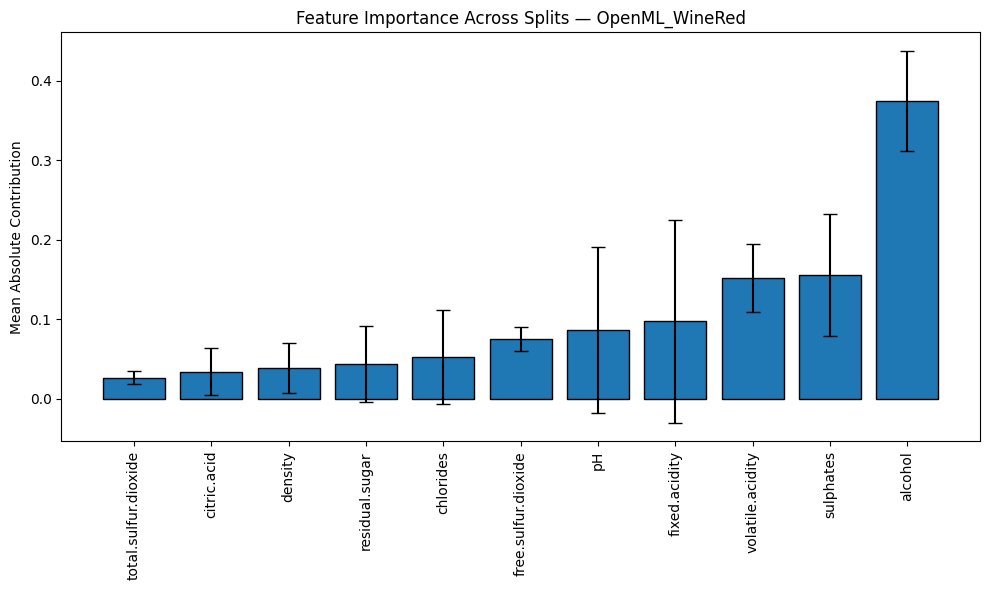

In [5]:
from utils import compute_mean_feature_importance
import matplotlib.pyplot as plt

# Compute per-model importances (one vector per avg_hist_data)
all_feature_importances = []

for avg_hist_data, mean_pred in zip(all_hist_data, all_mean_pred):
    feature_names, importances = compute_mean_feature_importance(avg_hist_data, mean_pred)
    all_feature_importances.append(importances)

all_feature_importances = np.vstack(all_feature_importances)  # shape: [num_models, num_features]

importance_mean = all_feature_importances.mean(axis=0)
importance_std  = all_feature_importances.std(axis=0)

sorted_idx = np.argsort(importance_mean)
sorted_features = np.array(feature_names)[sorted_idx]
sorted_mean = importance_mean[sorted_idx]
sorted_std  = importance_std[sorted_idx]

plt.figure(figsize=(10, 6))
plt.bar(sorted_features, sorted_mean, yerr=sorted_std, capsize=5, edgecolor="k")
plt.xticks(rotation=90)
plt.ylabel("Mean Absolute Contribution")
plt.title(f"Feature Importance Across Splits — {dataset_name}")
plt.tight_layout()
plt.show()


In [6]:
fold_rmses = []

for fold_idx in range(NUM_FOLDS):
    test_indices = fold_test_indices[fold_idx]
    y_test_fold = data_y[test_indices]

    # stack: [num_splits, n_test_samples] = [3, n_test]
    preds = np.vstack(all_preds_per_fold[fold_idx])
    ensemble_pred = preds.mean(axis=0)

    rmse = graph_builder.calculate_metric(
        y_test_fold,
        ensemble_pred,
        regression=True
    )
    fold_rmses.append(rmse)
    print(f"Fold {fold_idx+1} RMSE (test set only): {rmse:.4f} (n={len(test_indices)})")

fold_rmses = np.array(fold_rmses)
avg_rmse = fold_rmses.mean()
std_rmse = fold_rmses.std()

print(f"\nAverage Ensemble RMSE across folds (test sets only): {avg_rmse:.4f}")
print(f"Std of Ensemble RMSE across folds: {std_rmse:.4f}")


Fold 1 RMSE (test set only): 0.8845 (n=1300)
Fold 2 RMSE (test set only): 0.8685 (n=1300)
Fold 3 RMSE (test set only): 0.8739 (n=1299)
Fold 4 RMSE (test set only): 1.2823 (n=1299)
Fold 5 RMSE (test set only): 0.8817 (n=1299)

Average Ensemble RMSE across folds (test sets only): 0.9582
Std of Ensemble RMSE across folds: 0.1622


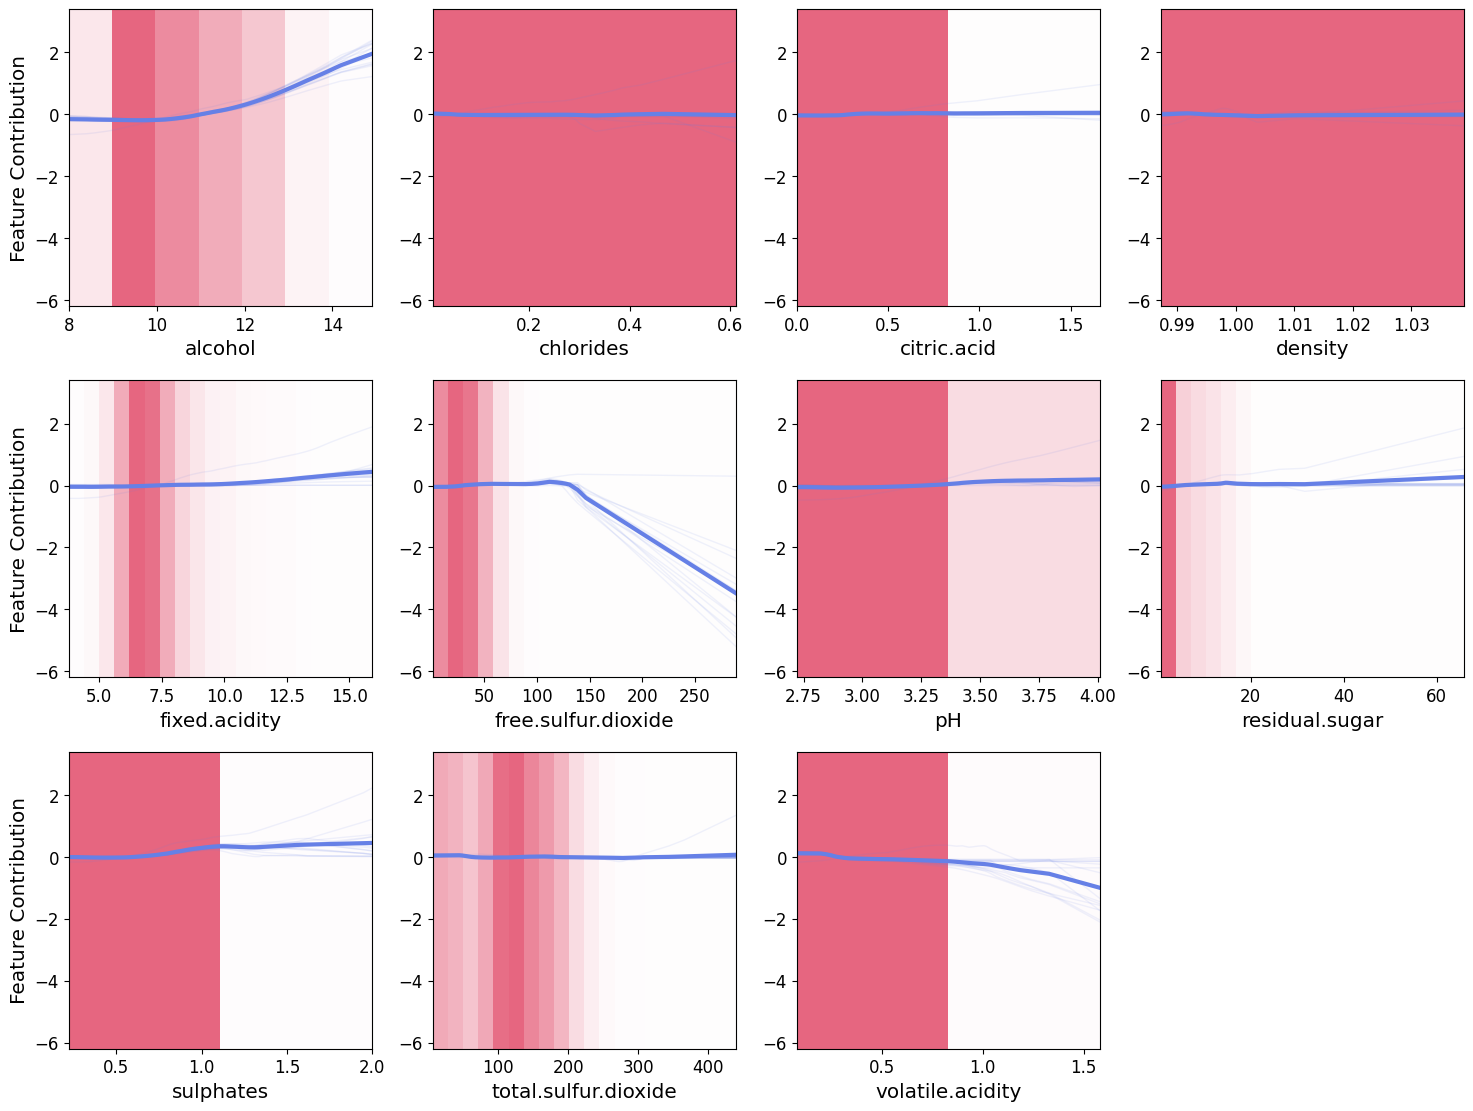

In [7]:
from utils import plot_nam_contributions_with_density



fig = plot_nam_contributions_with_density(
    hist_data=all_hist_data,
    unique_features=UNIQUE_FEATURES_ORIGINAL,
    single_features=SINGLE_FEATURES_ORIGINAL,
    categorical_names=CATEGORICAL_NAMES,
    col_mapping=COL_NAMES[dataset_name],
    feature_mapping=FEATURE_LABEL_MAPPING[dataset_name],
    mean_pred=all_mean_pred,
    feature_to_use=column_names,
   
)
